In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import torch
from torch.autograd.functional import jacobian
import sys
import copy
import pathlib
from pathlib import Path
cwd = Path().resolve()
import os
from os import path
# __file__ should be defined in this case
PARENT_DIR = path.dirname(cwd)
sys.path.append(PARENT_DIR)

from utils.utils import generate_normal, dB_to_lin, lin_to_dB, mse_loss, nmse_loss, \
    mse_loss_dB, load_saved_dataset, save_dataset, nmse_loss_std, mse_loss_dB_std, NDArrayEncoder, \
    partial_corrupt
from parameters_opt import get_parameters, A_fn, h_fn, f_lorenz_ukf, delta_t, J_test
from parameters_opt import get_parameters, A_fn, h_fn, delta_t, J_test, get_H_DANSE
from bin.generate_data import LorenzSSM
from src.ekf import EKF
from parse import parse

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/opt/anaconda3/envs/pytorch_env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [72]:
T_end = 1000 #X.shape[-1]

def dB_to_lin(x):
    return 10**(x/10)

def lin_to_dB(x):
    assert x != 0, "X is zero"
    return 10*np.log10(x)

def plot_3d_state_trajectory(X, legend='$\\mathbf{x}^{true}$', m='k-', savefig=False, savefig_name=None):
    
    # Creating 3d plot of the data
    #print(X.shape)
    plt.rcParams['font.size'] = 16
    if X.shape[-1] == 2:
        fig = plt.figure()
        ax = fig.add_subplot(111)
        ax.plot(X[:T_end,0], X[:T_end,1], m, label=legend)
        ax.set_xlabel('$X_1$')
        ax.set_ylabel('$X_2$')
        plt.legend()
        
    elif X.shape[-1] > 2:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        ax.plot(X[:T_end,0], X[:T_end,1], X[:T_end,2], m)#, label=legend)
        ax.set_xlabel('$X_1$')
        ax.set_ylabel('$X_2$')
        ax.set_zlabel('$X_3$')
        #plt.legend()
        plt.tight_layout()

    plt.tight_layout()
    if savefig:
        plt.savefig(savefig_name)
        #tikzplotlib.save(os.path.splitext(savefig_name)[0] + ".tex")
    #plt.show()
    return None

def plot_state_trajectory_axeswise(X, legend='$\\mathbf{x}^{true}$', m='k-', savefig=False, savefig_name=None):
    
    # Creating 3d plot of the data
    #print(X.shape)
    plt.rcParams['font.size'] = 16
    
    fig = plt.figure()
    ax = fig.add_subplot(311)
    ax.plot(X[:T_end,0], m)#, label=legend)
    ax.set_xlabel('$t$')
    ax.set_ylabel('$X_1$')
    ax = fig.add_subplot(312)
    ax.plot(X[:T_end,1], m)#, label=legend)
    ax.set_xlabel('$t$')
    ax.set_ylabel('$X_2$')
    ax = fig.add_subplot(313)
    ax.plot(X[:T_end,2], m)#, label=legend)
    ax.set_xlabel('$t$')
    ax.set_ylabel('$X_3$')
    #plt.legend()
    #plt.tight_layout()

    plt.tight_layout()
    if savefig:
        plt.savefig(savefig_name)
        #tikzplotlib.save(os.path.splitext(savefig_name)[0] + ".tex")
    #plt.show()
    return None

def plot_3d_measurment_trajectory(Y, legend='$\\mathbf{y}$', m='k-', savefig=False, savefig_name=None):
    
    # Creating 3d plot of the data
    #print(X.shape)
    plt.rcParams['font.size'] = 16
    if Y.shape[-1] == 2:
        fig = plt.figure()
        ax = fig.add_subplot(111)
        ax.plot(Y[:T_end,0], Y[:T_end,1], m, label=legend)
        ax.set_xlabel('$Y_1$')
        ax.set_ylabel('$Y_2$')
        plt.legend()
        
    elif Y.shape[-1] > 2:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        #ax.set_box_aspect((np.ptp(Y[:T_end,0]), np.ptp(Y[:T_end,1]), np.ptp(Y[:T_end,2])))
        #ax.set_box_aspect((1, 1, 1))
        ax.plot(Y[:T_end,0], Y[:T_end,1], Y[:T_end,2], m)#, label=legend)
        ax.set_xlabel('$Y_1$')
        ax.set_ylabel('$Y_2$')
        ax.set_zlabel('$Y_3$')
        #ax.axes.set_zlim3d([0, 60])
        #ax.set_ylim3d([-25, 50])
        #ax.axes.set_zlim3d([0, 50])
        #ax.set_ylim([ymin, ymax])
        #plt.legend()
        plt.tight_layout()

    plt.tight_layout()
    if savefig:
        plt.savefig(savefig_name)
        #tikzplotlib.save(os.path.splitext(savefig_name)[0] + ".tex")
    #plt.show()
    return None

In [73]:
smnr_dB_test = 10.0
test_data_file = "../data/synthetic_data/test_trajectories_m_3_n_1_LorenzSSMn1_data_T_2000_N_100_sigmae2_-10.0dB_smnr_{}dB.pkl".format(smnr_dB_test)
Z_XY_test = load_saved_dataset(
    filename=test_data_file
)
X = Z_XY_test['X']
Y = Z_XY_test['Y']
Cw = Z_XY_test['Cw']

In [74]:
X.shape

torch.Size([100, 2000, 3])

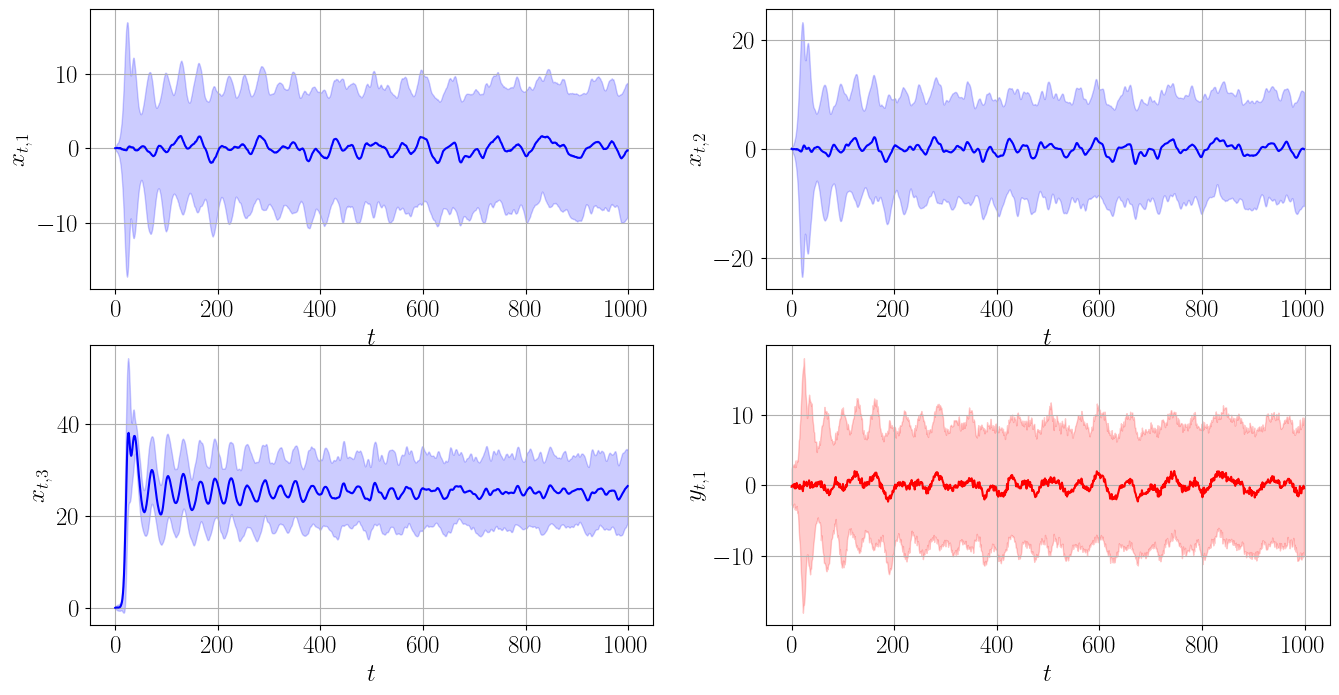

In [78]:
plt.figure(figsize=(16,8))
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 18
plt.subplot(2,2,1)
plt.plot(torch.mean(X, dim=0)[:T_end,0], color='blue')
plt.fill_between(
    x=torch.arange(T_end), 
    y1=torch.mean(X, dim=0)[:T_end,0] - torch.std(X, dim=0)[:T_end,0],
    y2=torch.mean(X, dim=0)[:T_end,0] + torch.std(X, dim=0)[:T_end,0],
    alpha=0.2,
    color='blue'
)
plt.xlabel('$t$', usetex=True)
plt.ylabel('$x_{t,1}$', usetex=True)
plt.grid(True)
#plt.tight_layout()

plt.subplot(2,2,2)
plt.plot(torch.mean(X, dim=0)[:T_end,1], color='blue')
plt.fill_between(
    x=torch.arange(T_end), 
    y1=torch.mean(X, dim=0)[:T_end,1] - torch.std(X, dim=0)[:T_end,1],
    y2=torch.mean(X, dim=0)[:T_end,1] + torch.std(X, dim=0)[:T_end,1],
    alpha=0.2,
    color='blue'
)
plt.xlabel('$t$', usetex=True)
plt.ylabel('$x_{t,2}$', usetex=True)
plt.grid(True)
#plt.tight_layout()

plt.subplot(2,2,3)
plt.plot(torch.mean(X, dim=0)[:T_end,2], color='blue')
plt.fill_between(
    x=torch.arange(T_end), 
    y1=torch.mean(X, dim=0)[:T_end,2] - torch.std(X, dim=0)[:T_end,2],
    y2=torch.mean(X, dim=0)[:T_end,2] + torch.std(X, dim=0)[:T_end,2],
    alpha=0.2,
    color='blue'
)
plt.xlabel('$t$', usetex=True)
plt.ylabel('$x_{t,3}$', usetex=True)
plt.grid(True)
#plt.tight_layout()

plt.subplot(2,2,4)
plt.plot(torch.mean(Y, dim=0)[:T_end,0], color='red')
plt.fill_between(
    x=torch.arange(T_end), 
    y1=torch.mean(Y, dim=0)[:T_end,0] - torch.std(Y, dim=0)[:T_end,0],
    y2=torch.mean(Y, dim=0)[:T_end,0] + torch.std(Y, dim=0)[:T_end,0],
    alpha=0.2,
    color='red'
)
plt.xlabel('$t$', usetex=True)
plt.ylabel('$y_{t,1}$', usetex=True)
plt.grid(True)
#plt.tight_layout()
'''
plt.subplot(3,2,4)
plt.plot(torch.mean(Y, dim=0)[:T_end,1], color='red')
plt.fill_between(
    x=torch.arange(T_end), 
    y1=torch.mean(Y, dim=0)[:T_end,1] - torch.std(Y, dim=0)[:T_end,1],
    y2=torch.mean(Y, dim=0)[:T_end,1] + torch.std(Y, dim=0)[:T_end,1],
    alpha=0.2,
    color='red'
)
plt.xlabel('$t$', usetex=True)
plt.ylabel('$y_{t,2}$', usetex=True)
plt.grid(True)
'''
plt.savefig('../figs_new_2024-12-04_danse_semidanse/LorenzSSMn3x1/ModTest_diff_smnr_nsup_20_Ntrain_1000_Ttrain_100_refactored/test_data_analysis.pdf')
plt.show()

In [79]:
from utils.plot_functions import plot_3d_state_trajectory

/Users/anubhabghosh/Documents/AnubhabsDocuments/KTH_PhD_Studies/Projects/CurrentProjects/Semi-DANSE/semi_danse/utils/plot_functions.py:438: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


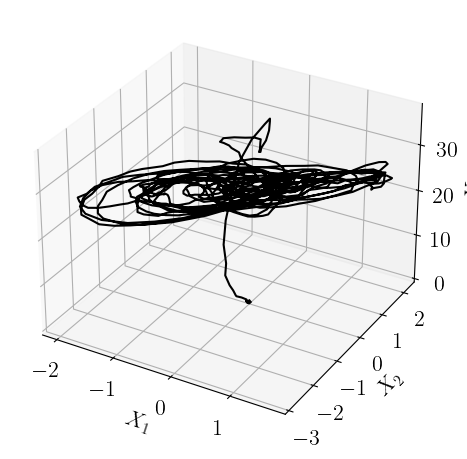

In [80]:
X_mean = torch.mean(X, dim=0)
plot_3d_state_trajectory(
    X=torch.cat((X_mean[:T_end,0].unsqueeze(1),
                X_mean[:T_end,1].unsqueeze(1),
                X_mean[:T_end,2].unsqueeze(1)), dim=1).numpy()
)